C:\Users\8J6010897\AppData\Local\Temp\ipykernel_81288\1585274300.py:30: DeprecationWarning: The class ``qiskit.primitives.estimator.Estimator`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseEstimatorV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Estimator` class is `StatevectorEstimator`.
  estimator = Estimator()
100%|██████████| 50/50 [00:01<00:00, 44.73it/s]


Final energy: -0.8125582007071157
Optimal primal vars: [2.51932401 0.3       ]
Lagrangian gap trajectory: [0.01174347 0.01280883 0.01395297 0.01517812 0.01648581 0.01787669
 0.0193503  0.02090492 0.02253728 0.02424243 0.02601348 0.02784141
 0.02971497 0.03162054 0.03354211 0.03546134 0.03735771 0.03920877
 0.04099056 0.04267805 0.04424581 0.04566869 0.04692257 0.04798523
 0.04883708 0.04946193 0.04984763 0.04998658 0.049876   0.0495181
 0.04891995 0.0480932  0.04705361 0.04582042 0.04441559 0.04286306
 0.0411879  0.03941557 0.03757115 0.03567876 0.03376106 0.03183878
 0.02993054 0.02805261 0.02621887 0.02444086 0.02272783 0.02108691
 0.01952326 0.01804032]


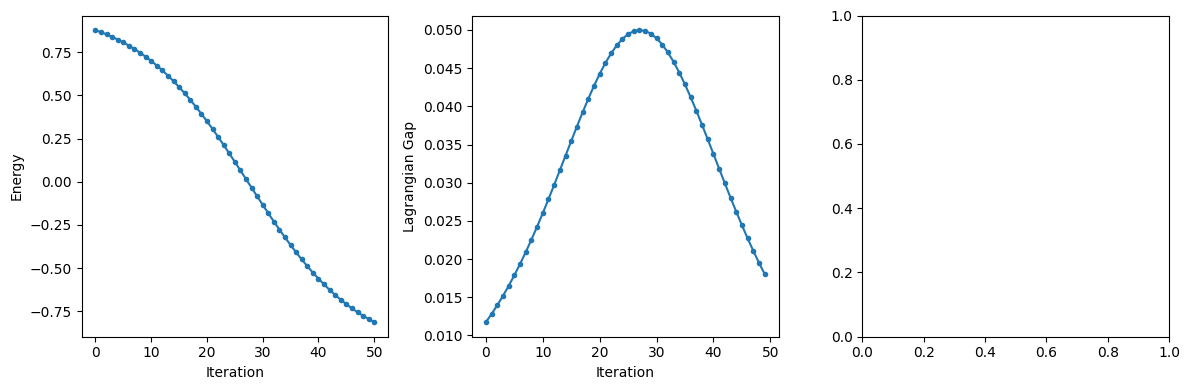

In [4]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit import Parameter
from qiskit.primitives import Estimator
from qiskit_algorithms.gradients import ParamShiftEstimatorGradient
import numpy as np
from vqe_optimization_goldstein import VQECOpt_goldstein


# Mock test case function to verify that the implementation behaves as intended
def test_vqec_opt_hkn():
    # Define a simple 2-qubit operator (Pauli Z)
    qubit_op = SparsePauliOp.from_list([("ZZ", 1.0)])

    # Define simple constraint operators (Pauli X on qubits)
    constr_ops = [
        SparsePauliOp.from_list([("IX", 1.0)]),  # X on qubit 2
        SparsePauliOp.from_list([("XI", 1.0)])   # X on qubit 1
    ]

    # Define a simple ansatz with parameterized gates
    theta_0 = Parameter('θ0')  # Define parameters
    theta_1 = Parameter('θ1')

    ansatz = QuantumCircuit(2)
    ansatz.rx(theta_0, 0)  # RX on qubit 1
    ansatz.rz(theta_1, 1)  # RZ on qubit 2

    # Initialize Qiskit's Estimator
    estimator = Estimator()

    # Initialize gradient using ParamShiftEstimatorGradient
    gradient = ParamShiftEstimatorGradient(estimator)

    # Initial test parameters
    initial_params = np.array([0.5, 0.3])  # Initial params for ansatz
    initial_dual_vars = np.array([0.1, 0.1])  # Dual variables

    # Initialize VQEC optimizer
    vqec = VQECOpt_goldstein(
        qubit_op=qubit_op,
        constr_ops=constr_ops,
        ansatz=ansatz,
        estimator=estimator,
        gradient=gradient,
        initial_params=initial_params,
        initial_dual_vars=initial_dual_vars,
        primal_perturb_step=0.05,   # Initial primal perturbation step
        dual_perturb_step=0.05,    # Initial dual perturbation step (fixed)
        max_iter=50                # Limit iterations for testing
    )

    # Run the optimizer
    result = vqec.optimize_primal_dual()

    # Output results
    print(f"Final energy: {result.energies[-1]}")
    print(f"Optimal primal vars: {result.optimal_primal_vars}")
    print(f"Lagrangian gap trajectory: {result.lagrangian_gap_trajectory}")
    #print(f"Gradient norms: {result.gradient_norms}")

    return result

# Run the test case in the notebook
test_result = test_vqec_opt_hkn()

# Plot results to visualize optimization progress
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].plot(test_result.energies, label="Energy", marker=".")
ax[0].set_xlabel("Iteration")
ax[0].set_ylabel("Energy")

ax[1].plot(test_result.lagrangian_gap_trajectory, label="Lagrangian Gap", marker=".")
ax[1].set_xlabel("Iteration")
ax[1].set_ylabel("Lagrangian Gap")

# ax[2].plot(test_result.gradient_norms, label="Gradient Norms", marker=".")
# ax[2].set_xlabel("Iteration")
# ax[2].set_ylabel("Gradient Norms")

plt.tight_layout()
plt.show()
